In [ ]:
import os
import torch
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score
import numpy as np
from PIL import Image

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import shutil

shutil.copytree(path, "/content/chest_xray_dataset")


'/content/chest_xray_dataset'

In [ ]:
base_path = "/content/chest_xray_dataset/chest_xray"


In [ ]:
#Data checking

for folder in ["train", "val", "test"]:
    normal_path = os.path.join(base_path, folder, "NORMAL")
    pneumonia_path = os.path.join(base_path, folder, "PNEUMONIA")

    print(f"\n{folder.upper()} DATA")
    print("Normal images :", len(os.listdir(normal_path)))
    print("Pneumonia images :", len(os.listdir(pneumonia_path)))



TRAIN DATA
Normal images : 1341
Pneumonia images : 3875

VAL DATA
Normal images : 8
Pneumonia images : 8

TEST DATA
Normal images : 234
Pneumonia images : 390


# preprocessing


In [ ]:

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224,224)),      # make all images same size
    transforms.RandomHorizontalFlip(), # augmentation
    transforms.RandomRotation(10),     # augmentation
    transforms.ToTensor(),             # convert image to tensor
    transforms.Normalize([0.5], [0.5]) # normalization
])

# Validation & Test (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


#Load Dataset


In [ ]:

train_dataset = ImageFolder(base_path + "/train", transform=train_transform)
val_dataset = ImageFolder(base_path + "/val", transform=test_transform)
test_dataset = ImageFolder(base_path + "/test", transform=test_transform)


In [ ]:
#Loads images in batches

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 163
Validation batches: 1
Test batches: 20


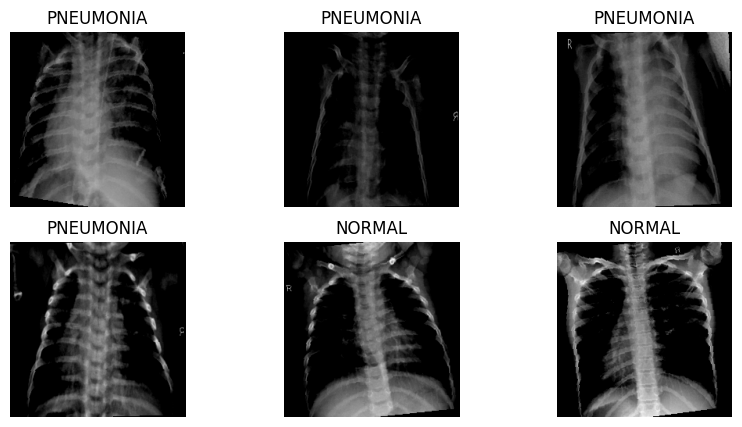

In [ ]:
import matplotlib.pyplot as plt

# Get one batch of images
images, labels = next(iter(train_loader))

# Class names
classes = train_dataset.classes   # ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(10,5))

for i in range(6):   # show first 6 images
    plt.subplot(2,3,i+1)

    img = images[i].permute(1,2,0)  # change tensor shape for display
    plt.imshow(img.squeeze(), cmap="gray")

    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()


In [ ]:
print("Classes:", train_dataset.classes)
print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Test Images:", len(test_dataset))


Classes: ['NORMAL', 'PNEUMONIA']
Training Images: 5216
Validation Images: 16
Test Images: 624


#Baseline CNN Model

In [ ]:
#Baseline CNN Code

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)


In [ ]:
#Loss & Optimizer

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [ ]:
#Training with base line CNN

def train_model(model, train_loader, val_loader, epochs=5):

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}")

train_model(model, train_loader, val_loader, epochs=5)


Epoch [1/5], Loss: 0.2543
Epoch [2/5], Loss: 0.1568
Epoch [3/5], Loss: 0.1250
Epoch [4/5], Loss: 0.1193
Epoch [5/5], Loss: 0.1111


In [ ]:
#Evaluation + Metrics

def evaluate_baseline(model, test_loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Accuracy
    acc = accuracy_score(all_labels, all_preds)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("Accuracy :", acc)
    print("\nConfusion Matrix:")
    print(cm)

evaluate_baseline(model, test_loader)

Accuracy : 0.7692307692307693

Confusion Matrix:
[[ 94 140]
 [  4 386]]


# Transfer Learning using ResNet18

In [ ]:
#model deployment

model_tl = models.resnet18(pretrained=True)

# Freeze early layers (feature extractor)
for param in model_tl.parameters():
    param.requires_grad = False

# Replace final layer for binary classification
model_tl.fc = nn.Linear(model_tl.fc.in_features, 1)

model_tl = model_tl.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


In [ ]:
#Loss & Optimizer

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_tl.parameters(), lr=1e-4)


In [ ]:
#Training model

def train_model(model, train_loader, val_loader, epochs=10):

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {train_loss/len(train_loader):.4f}")


In [ ]:
# Validation

train_model(model_tl, train_loader, val_loader, epochs=10)


Epoch [1/10] Loss: 0.5338
Epoch [2/10] Loss: 0.4286
Epoch [3/10] Loss: 0.3647
Epoch [4/10] Loss: 0.3199
Epoch [5/10] Loss: 0.2852
Epoch [6/10] Loss: 0.2730
Epoch [7/10] Loss: 0.2503
Epoch [8/10] Loss: 0.2405
Epoch [9/10] Loss: 0.2270
Epoch [10/10] Loss: 0.2235


In [ ]:
#Evaluation Metrics

def evaluate_transfer(model, test_loader):

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Accuracy
    acc = accuracy_score(all_labels, all_preds)

    # AUC
    auc = roc_auc_score(all_labels, all_probs)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    TN, FP, FN, TP = cm.ravel()

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    print(" Accuracy :", acc)
    print(" AUC :", auc)
    print(" Sensitivity (Recall for Pneumonia) :", sensitivity)
    print(" Specificity (Normal detection) :", specificity)

    return cm

cm = evaluate_transfer(model_tl, test_loader)


 Accuracy : 0.8637820512820513
 AUC : 0.9410475564321719
 Sensitivity (Recall for Pneumonia) : 0.9487179487179487
 Specificity (Normal detection) : 0.7222222222222222


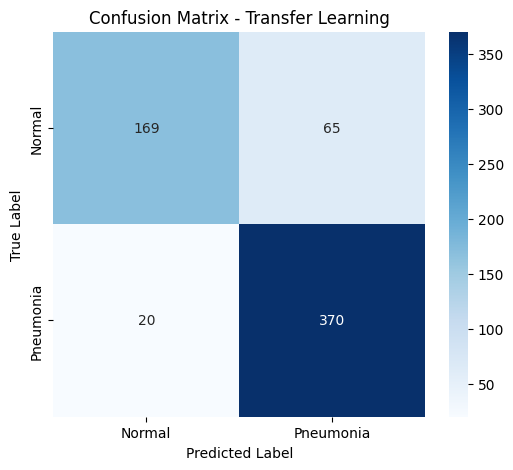

In [ ]:
# Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Transfer Learning")
plt.show()


# Predict image (normal / pneumonia)

In [ ]:
from PIL import Image

img = Image.open('/content/chest_xray_dataset/chest_xray/train/NORMAL/IM-0115-0001.jpeg').convert("RGB")
# first data of the normal sample img

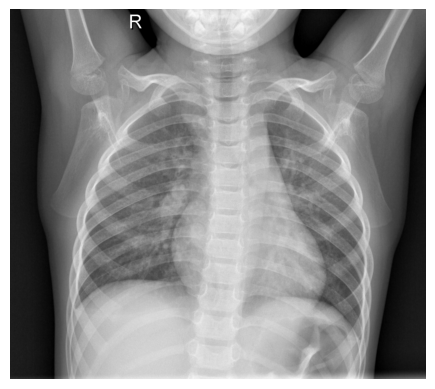

In [ ]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
#Transform the image

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(img).unsqueeze(0).to(device)


In [ ]:
# Predict

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    prob = torch.sigmoid(output)

if prob.item() > 0.5:
    print("Prediction: Pneumonia")
else:
    print("Prediction: Normal")


Prediction: Normal
